# 6. Validación estadística: mortalidad atribuible al calor

Análisis epidemiológico de la relación entre temperatura extrema y mortalidad
en adultos mayores de la Región Metropolitana, 1990–2026.

**Fuentes:**
- Temperatura: ERA5 reanalysis (Open-Meteo API), resolución diaria
- Mortalidad: DEIS – Defunciones 1990–2023 + 2024–2026 (cifras oficiales)

**Metodología:** exceso de mortalidad sobre baseline estacional con estructura
de rezago (lag 0–6 días). Riesgo relativo por capítulo CIE-10.

---

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PATH_DEF_1990 = '../data/egresos/DEFUNCIONES_FUENTE_DEIS_1990_2023_CIFRAS_OFICIALES.csv'
PATH_DEF_2024 = '../data/egresos/DEFUNCIONES_FUENTE_DEIS_2024_2026_23062026.csv'
FECHA_FIN     = '2026-06-20'   # ultimo dia disponible en el archivo 2024-2026

# Años excluidos del baseline: COVID (2020-2022) + olas de calor severas conocidas
ANIOS_EXCLUIR_BASELINE = [2017, 2019, 2020, 2021, 2022, 2023]
MESES_VERANO = [11, 12, 1, 2, 3]
print('Configuracion lista')

Configuracion lista


## 1. Temperatura ERA5 (1990–2026)

In [2]:
print('Descargando T_max ERA5 1990-2026...')
r = requests.get(
    'https://archive-api.open-meteo.com/v1/archive'
    '?latitude=-33.49&longitude=-70.58'
    f'&start_date=1990-01-01&end_date={FECHA_FIN}'
    '&daily=temperature_2m_max,temperature_2m_min'
    '&timezone=America%2FSantiago',
    timeout=120
)
d = r.json()
df_t = pd.DataFrame({
    'fecha': pd.to_datetime(d['daily']['time']),
    'tmax':  d['daily']['temperature_2m_max'],
    'tmin':  d['daily']['temperature_2m_min'],
}).set_index('fecha')
df_t['mes']  = df_t.index.month
df_t['anio'] = df_t.index.year

verano_mask = df_t['mes'].isin(MESES_VERANO)
p90 = df_t.loc[verano_mask, 'tmax'].quantile(0.90)
p95 = df_t.loc[verano_mask, 'tmax'].quantile(0.95)

print(f'ERA5: {df_t.index.min().date()} - {df_t.index.max().date()}')
print(f'P90 T_max verano: {p90:.1f}C  |  P95: {p95:.1f}C')

Descargando T_max ERA5 1990-2026...
ERA5: 1990-01-01 - 2026-06-20
P90 T_max verano: 30.0C  |  P95: 31.0C


## 2. Defunciones RM 65+

In [3]:
print('Cargando defunciones DEIS 1990-2026...')

def _cargar_def(path):
    df = pd.read_csv(path, encoding='latin-1', sep=';', low_memory=False)
    df['fecha'] = pd.to_datetime(df['FECHA_DEF'], errors='coerce')
    return df

df_raw = pd.concat([_cargar_def(PATH_DEF_1990), _cargar_def(PATH_DEF_2024)],
                   ignore_index=True)
print(f'  Total filas cargadas: {len(df_raw):,}')

mask = (
    df_raw['NOMBRE_REGION'].str.contains('Metropolitana', na=False) &
    (df_raw['EDAD_TIPO'] == 1) & (df_raw['EDAD_CANT'] >= 65) &
    (df_raw['fecha'].dt.year >= 1990)
)
df_def = df_raw[mask].copy()
df_def['anio'] = df_def['fecha'].dt.year
df_def['mes']  = df_def['fecha'].dt.month
df_def['doy']  = df_def['fecha'].dt.dayofyear

bins   = [65, 75, 85, 120]
labels = ['65-74', '75-84', '85+']
df_def['grupo_edad'] = pd.cut(df_def['EDAD_CANT'], bins=bins, labels=labels, right=False)

print(f'Defunciones RM 65+ (1990-2026): {len(df_def):,}')
print(f'Rango: {df_def["fecha"].min().date()} - {df_def["fecha"].max().date()}')
print(df_def['grupo_edad'].value_counts().sort_index())

Cargando defunciones DEIS 1990-2026...
  Total filas cargadas: 3,492,928
Defunciones RM 65+ (1990-2026): 905,066
Rango: 1990-01-01 - 2026-06-20
grupo_edad
65-74    254468
75-84    334606
85+      315989
Name: count, dtype: int64


## 3. Baseline estacional y exceso de mortalidad

In [4]:
# Serie diaria total RM 65+
diario = df_def.groupby('fecha').size().rename('muertes').reset_index()
diario = (diario.set_index('fecha')
          .reindex(pd.date_range('1990-01-01', FECHA_FIN), fill_value=0)
          .reset_index().rename(columns={'index': 'fecha'}))
diario['anio'] = diario['fecha'].dt.year
diario['mes']  = diario['fecha'].dt.month
diario['doy']  = diario['fecha'].dt.dayofyear

# Baseline: media por DOY +-10 dias, excluyendo años problematicos
base_df = diario[~diario['anio'].isin(ANIOS_EXCLUIR_BASELINE)]

baseline_rows = []
for doy in range(1, 367):
    sub = base_df[base_df['doy'].between(max(1, doy-10), min(366, doy+10))]
    baseline_rows.append({
        'doy': doy,
        'base_mean': sub['muertes'].mean(),
        'base_std':  sub['muertes'].std()
    })
baseline = pd.DataFrame(baseline_rows)

diario = diario.merge(baseline, on='doy', how='left')
diario['exceso'] = diario['muertes'] - diario['base_mean']
diario['zscore'] = diario['exceso'] / diario['base_std'].replace(0, np.nan)
diario = diario.set_index('fecha')
diario = diario.join(df_t[['tmax', 'tmin']], how='left')

print('Baseline calculado')
print(diario[['muertes', 'base_mean', 'exceso', 'zscore']].describe().round(2))

Baseline calculado
        muertes  base_mean    exceso    zscore
count  13320.00   13320.00  13320.00  13320.00
mean      67.95      62.78      5.16      0.30
std       23.39       8.17     21.56      1.24
min       14.00      53.01    -57.41     -2.95
25%       51.00      55.96    -10.70     -0.62
50%       64.00      59.18      1.62      0.10
75%       82.00      70.06     18.27      1.07
max      289.00      77.69    214.60     10.97


## 4. Correlación T_max vs exceso — estructura de rezago

In [ ]:
df_ver = diario[diario['mes'].isin(MESES_VERANO)].copy()

lags = range(0, 8)
lag_results = []
for lag in lags:
    t_lag = df_ver['tmax'].shift(lag)
    valid = df_ver['exceso'].notna() & t_lag.notna()
    r, p = sp.pearsonr(t_lag[valid], df_ver['exceso'][valid])
    lag_results.append({'lag': lag, 'r': r, 'p': p, 'n': valid.sum()})
df_lag = pd.DataFrame(lag_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = ['#c0392b' if p < 0.05 else '#bdc3c7' for p in df_lag['p']]
bars = ax.bar(df_lag['lag'], df_lag['r'], color=colors, edgecolor='white', width=0.6)
for bar, row in zip(bars, df_lag.itertuples()):
    sig = '***' if row.p < 0.001 else ('**' if row.p < 0.01 else ('*' if row.p < 0.05 else ''))
    if sig:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                sig, ha='center', fontsize=10, color='#c0392b')
ax.set_xlabel('Rezago (dias)')
ax.set_ylabel('r de Pearson')
ax.set_title('Correlacion T$_{max}$ vs exceso de mortalidad\nRM 65+, veranos 1990-2026')
ax.set_xticks(df_lag['lag'])
ax.axhline(0, color='black', linewidth=0.8)
red_patch = mpatches.Patch(color='#c0392b', label='p < 0.05')
ax.legend(handles=[red_patch], fontsize=9)

ax2 = axes[1]
hot = df_ver[df_ver['tmax'] >= 28].copy()
ax2.scatter(hot['tmax'], hot['exceso'], alpha=0.3, s=15,
            color='#e67e22', edgecolors='none')
valid = hot[['tmax', 'exceso']].dropna()
m, b, r, p, _ = sp.linregress(valid['tmax'], valid['exceso'])
x_line = np.linspace(valid['tmax'].min(), valid['tmax'].max(), 100)
ax2.plot(x_line, m * x_line + b, color='#c0392b', linewidth=2,
         label=f'r={r:.2f}, p={p:.3f}')
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.set_xlabel('T$_{max}$ (C)')
ax2.set_ylabel('Exceso de mortalidad (muertes/dia sobre baseline)')
ax2.set_title('T$_{max}$ vs exceso (dias de verano >= 28 C)\nRM 65+, 1990-2026')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/val_correlacion_lag.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_lag.to_string(index=False))

## 5. Exceso por capítulo CIE-10 (excluyendo años COVID)

In [ ]:
# Excluir 2020-2022 (COVID distorsiona codificacion de causas)
ANIOS_COVID = [2020, 2021, 2022]
df_no_covid = df_def[
    ~df_def['anio'].isin(ANIOS_COVID) &
    df_def['mes'].isin(MESES_VERANO)
].copy()

df_t_nc = df_t[~df_t['anio'].isin(ANIOS_COVID) & df_t['mes'].isin(MESES_VERANO)]
hot_dates_nc = set(df_t_nc.index[df_t_nc['tmax'] >= p90])

# Ventana lag 0-3
hot_lag_nc = set()
for hd in hot_dates_nc:
    for lg in range(4):
        hot_lag_nc.add(hd + pd.Timedelta(days=lg))

df_no_covid['es_calor'] = df_no_covid['fecha'].isin(hot_lag_nc)

# Totales para calcular RR correctamente
# RR = (muertes_causa_X_en_calor / muertes_totales_en_calor)
#    / (muertes_causa_X_en_frio  / muertes_totales_en_frio)
# Esto mide si la fraccion de muertes por causa X es mayor en dias de calor
n_total_calor = int(df_no_covid['es_calor'].sum())
n_total_frio  = int((~df_no_covid['es_calor']).sum())
print(f'Muertes en periodo calor (lag 0-3): {n_total_calor:,}')
print(f'Muertes en periodo frio:            {n_total_frio:,}')

cie_rows = []
caps = df_no_covid.groupby(['GLOSA_CAPITULO_DIAG1', 'es_calor']).size().unstack(fill_value=0)
caps.columns = ['frio', 'calor']
for cap, row in caps.iterrows():
    if row['calor'] < 20 or row['frio'] < 20 or pd.isna(cap):
        continue
    rr = (row['calor'] / n_total_calor) / (row['frio'] / n_total_frio)
    obs = [[row['calor'],           n_total_calor - row['calor']],
           [row['frio'],            n_total_frio  - row['frio']]]
    try:
        _, p, _, _ = sp.chi2_contingency(obs)
    except Exception:
        p = 1.0
    nombre = str(cap).split('(')[0].strip()
    if len(nombre) > 48:
        nombre = nombre[:46] + '..'
    cie_rows.append({'capitulo': nombre, 'n_calor': int(row['calor']),
                     'RR': rr, 'exceso_pct': (rr - 1) * 100, 'p': p})

df_cie = pd.DataFrame(cie_rows).sort_values('exceso_pct', ascending=False)
df_cie['sig'] = df_cie['p'].apply(
    lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else '')))

# Excluir "Codigos para propositos especiales" (artefacto de codificacion)
df_cie_plot = df_cie[~df_cie['capitulo'].str.contains('especiales|special', case=False, na=False)]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if r > 1 else '#2980b9' for r in df_cie_plot['RR']]
bars = ax.barh(df_cie_plot['capitulo'], df_cie_plot['exceso_pct'],
               color=colors, alpha=0.8, edgecolor='white')
for bar, (_, row) in zip(bars, df_cie_plot.iterrows()):
    if row['sig']:
        x = bar.get_width()
        ax.text(x + 0.3, bar.get_y() + bar.get_height() / 2,
                row['sig'], va='center', fontsize=9, color='#333')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Exceso de mortalidad en dias de calor (% vs dias frios)')
ax.set_title('Fraccion de muertes por capitulo CIE-10 en dias de calor extremo\n'
             'RM 65+, veranos 1990-2019 y 2023-2026 (excl. COVID)')
plt.tight_layout()
plt.savefig('../outputs/val_exceso_cie10.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_cie[['capitulo', 'n_calor', 'RR', 'exceso_pct', 'sig']].to_string(index=False, float_format='%.3f'))

## 6. Serie temporal de exceso — eventos de calor identificados

In [ ]:
diario_ver = diario[diario['mes'].isin(MESES_VERANO)].copy()
diario_ver['hot'] = (diario_ver['tmax'] >= p90).astype(int)
diario_ver['ola_id'] = (diario_ver['hot'].diff().fillna(0) != 0).cumsum()

olas = []
for oid, grp in diario_ver[diario_ver['hot'] == 1].groupby('ola_id'):
    if len(grp) < 2:
        continue
    fin_ext  = grp.index.max() + pd.Timedelta(days=3)
    ventana  = diario.loc[grp.index.min():fin_ext, 'exceso'].sum()
    zscore_m = diario.loc[grp.index.min():fin_ext, 'zscore'].max()
    olas.append({
        'inicio':      grp.index.min(),
        'fin':         grp.index.max(),
        'n_dias':      len(grp),
        'tmax_max':    grp['tmax'].max(),
        'exceso_acum': ventana,
        'zscore_max':  zscore_m,
    })
df_olas = pd.DataFrame(olas).sort_values('exceso_acum', ascending=False)

print('Top 15 olas de calor por exceso acumulado:')
print(df_olas.head(15).to_string(index=False, float_format='%.1f'))

# Scatter: solo etiquetar top 8 por exceso para no saturar
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df_olas['tmax_max'], df_olas['exceso_acum'],
    s=df_olas['n_dias'] * 25, alpha=0.7,
    c=df_olas['exceso_acum'], cmap='YlOrRd', edgecolors='grey', linewidth=0.5
)
top8 = df_olas.nlargest(8, 'exceso_acum')
for _, row in top8.iterrows():
    ax.annotate(row['inicio'].strftime('%b %Y'),
                (row['tmax_max'], row['exceso_acum']),
                textcoords='offset points', xytext=(7, 3), fontsize=8)
# Marcar evento modelado (Ene 2019)
ola_2019 = df_olas[df_olas['inicio'].dt.strftime('%Y-%m') == '2019-01'].head(1)
if not ola_2019.empty:
    ax.scatter(ola_2019['tmax_max'], ola_2019['exceso_acum'],
               s=200, marker='*', color='black', zorder=5, label='Ene 2019 (modelado)')
    ax.legend(fontsize=9)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.colorbar(sc, ax=ax, label='Exceso acumulado (muertes)')
ax.set_xlabel('T$_{max}$ maxima de la ola (C)')
ax.set_ylabel('Exceso acumulado de mortalidad (lag 0-3)')
ax.set_title('Olas de calor 1990-2026: intensidad vs exceso de mortalidad RM 65+')
ax.text(0.02, 0.97, 'Tamano = duracion de la ola',
        transform=ax.transAxes, fontsize=8, va='top', color='grey')
plt.tight_layout()
plt.savefig('../outputs/val_olas_exceso.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Serie temporal de exceso y contextualización del evento modelado

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel izquierdo: serie temporal Nov 2018 – Mar 2019 ──────────────────────
ax = axes[0]

mascara = (diario.index >= '2018-11-01') & (diario.index <= '2019-03-31')
serie = diario[mascara].copy()

ax.bar(serie.index, serie['exceso'], color='steelblue', alpha=0.55, width=1, label='Exceso diario')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

ola_ini = pd.Timestamp('2019-01-25')
ola_fin = pd.Timestamp('2019-02-01')
ax.axvspan(ola_ini, ola_fin, color='orange', alpha=0.30, label='Ola de calor (26 ene)')

mm7 = serie['exceso'].rolling(7, center=True).mean()
ax.plot(serie.index, mm7, color='crimson', linewidth=2.0, label='Media movil 7d')

ax.set_title('Exceso de mortalidad RM 65+\nNov 2018 – Mar 2019', fontsize=12)
ax.set_xlabel('Fecha')
ax.set_ylabel('Muertes sobre baseline (RM 65+)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Panel derecho: comparacion acumulada olas mayores ────────────────────────
ax2 = axes[1]

# Ventanas de 30 dias a partir del inicio de cada evento
eventos = {
    'Ene 2019\n(modelada)': ('2019-01-15', '2019-02-14'),
    'Feb 2023':             ('2023-02-01', '2023-03-03'),
    'Ene 2024':             ('2024-01-05', '2024-02-04'),
}

excesos_acum = {}
for nombre, (ini, fin) in eventos.items():
    mask = (diario.index >= ini) & (diario.index <= fin)
    excesos_acum[nombre] = diario.loc[mask, 'exceso'].sum()

colores_ev = ['#e07b3c', '#2980b9', '#27ae60']
barras = ax2.bar(list(excesos_acum.keys()), list(excesos_acum.values()),
                 color=colores_ev, edgecolor='black', linewidth=0.7)

for bar, val in zip(barras, excesos_acum.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             f'+{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Exceso acumulado RM 65+ por evento de calor\n(ventana 30 dias desde inicio)', fontsize=12)
ax2.set_ylabel('Muertes acumuladas sobre baseline')
ax2.set_ylim(0, max(excesos_acum.values()) * 1.18)

plt.tight_layout()
plt.savefig('../outputs/val_serie_olas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Guardado: outputs/val_serie_olas.png")
print("Exceso acumulado (30 dias):")
for nombre, val in excesos_acum.items():
    print(f"  {nombre.replace(chr(10), ' ')}: +{int(val)} muertes")


## 8. Estratificación por grupo etario

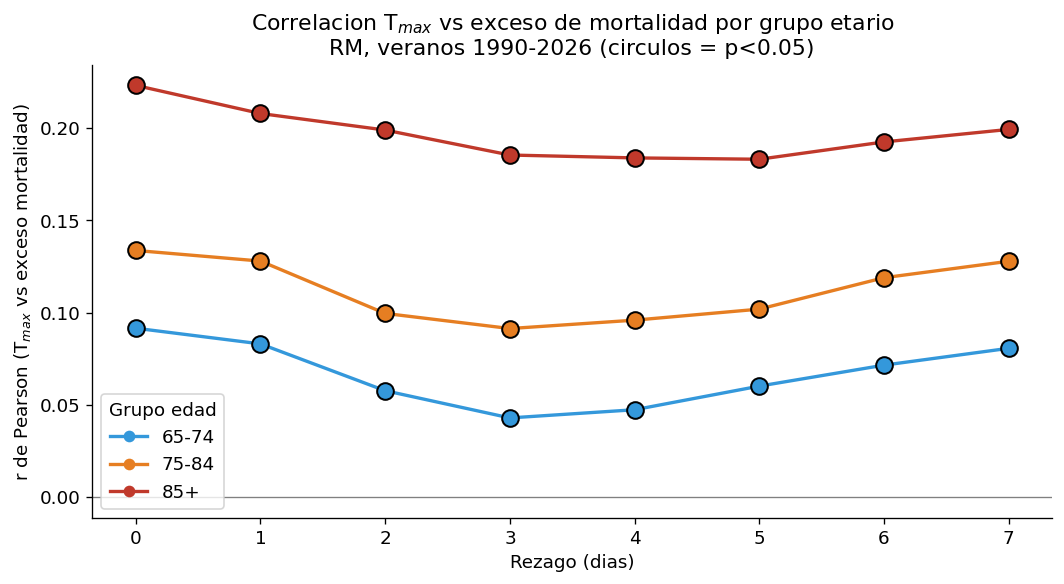


65-74:
 lag        r            p
   0 0.091490 9.141475e-12
   1 0.083004 6.248816e-10
   2 0.057640 1.785976e-05
   3 0.042889 1.419012e-03
   4 0.047319 4.309763e-04
   5 0.060119 7.687245e-06
   6 0.071482 1.033047e-07
   7 0.080609 1.952642e-09

75-84:
 lag        r            p
   0 0.133620 1.799582e-23
   1 0.127874 1.299967e-21
   2 0.099512 1.181505e-13
   3 0.091315 1.014361e-11
   4 0.095856 9.086167e-13
   5 0.101832 3.182317e-14
   6 0.118858 7.484742e-19
   7 0.127768 1.475808e-21

85+:
 lag        r            p
   0 0.223054 2.317236e-63
   1 0.207823 4.724588e-55
   2 0.198852 1.879360e-50
   3 0.185327 6.195840e-44
   4 0.183767 3.303467e-43
   5 0.183038 7.248937e-43
   6 0.192421 2.906189e-47
   7 0.199205 1.384964e-50


In [8]:
grupos = ['65-74', '75-84', '85+']
lag_por_grupo = {}

for gedad in grupos:
    df_g = df_def[
        (df_def['grupo_edad'] == gedad) &
        df_def['mes'].isin(MESES_VERANO)
    ].copy()
    diario_g = df_g.groupby('fecha').size().rename('muertes').reindex(
        pd.date_range('1990-01-01', FECHA_FIN), fill_value=0
    )
    diario_g = diario_g.to_frame()
    diario_g['anio'] = diario_g.index.year
    diario_g['mes']  = diario_g.index.month
    diario_g['doy']  = diario_g.index.dayofyear

    base_g = diario_g[~diario_g['anio'].isin(ANIOS_EXCLUIR_BASELINE)]
    bl_rows = []
    for doy in range(1, 367):
        sub = base_g[base_g['doy'].between(max(1, doy-10), min(366, doy+10))]
        bl_rows.append({'doy': doy, 'base_mean': sub['muertes'].mean(),
                        'base_std': sub['muertes'].std()})
    bl = pd.DataFrame(bl_rows)
    diario_g = diario_g.reset_index().merge(bl, on='doy').set_index('index')
    diario_g.index.name = 'fecha'
    diario_g['exceso'] = diario_g['muertes'] - diario_g['base_mean']
    diario_g = diario_g.join(df_t[['tmax']], how='left')
    df_ver_g = diario_g[diario_g['mes'].isin(MESES_VERANO)]

    res = []
    for lag in range(8):
        t_lag = df_ver_g['tmax'].shift(lag)
        valid = df_ver_g['exceso'].notna() & t_lag.notna()
        r, p = sp.pearsonr(t_lag[valid], df_ver_g['exceso'][valid])
        res.append({'lag': lag, 'r': r, 'p': p})
    lag_por_grupo[gedad] = pd.DataFrame(res)

# Grafico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
colors_g = {'65-74': '#3498db', '75-84': '#e67e22', '85+': '#c0392b'}
for gedad, df_lg in lag_por_grupo.items():
    ax.plot(df_lg['lag'], df_lg['r'], marker='o', linewidth=2,
            label=gedad, color=colors_g[gedad])
    for _, row in df_lg.iterrows():
        if row['p'] < 0.05:
            ax.plot(row['lag'], row['r'], 'o', markersize=10,
                    color=colors_g[gedad], markeredgecolor='black', markeredgewidth=1.2)
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Rezago (dias)')
ax.set_ylabel('r de Pearson (T$_{max}$ vs exceso mortalidad)')
ax.set_title('Correlacion T$_{max}$ vs exceso de mortalidad por grupo etario\n'
             'RM, veranos 1990-2026 (circulos = p<0.05)')
ax.legend(title='Grupo edad')
ax.set_xticks(range(8))
plt.tight_layout()
plt.savefig('../outputs/val_lag_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()

for g, df_lg in lag_por_grupo.items():
    print(f'\n{g}:')
    print(df_lg.to_string(index=False))

## 9. Análisis comunal — ola de calor enero 2019

> **Nota metodológica:** el n por comuna es muy pequeño (1–4 muertes/día en la mayoría de las comunas).
> Los porcentajes deben interpretarse con cautela — la variabilidad aleatoria domina a este nivel de
> desagregación y los valores extremos (positivos o negativos) son en gran medida ruido estadístico,
> no señal epidemiológica real. Este análisis es exploratorio y no permite inferencia causal a nivel comunal.

In [ ]:
# Ola 26 ene - 1 feb 2019 (+ lag 3), baseline = 5-25 enero 2019
OLA_INI  = '2019-01-26'
OLA_FIN  = '2019-02-01'
BASE_INI = '2019-01-05'
BASE_FIN = '2019-01-25'
N_OLA    = 7
N_BASE   = 21

com_ola  = df_def[(df_def['fecha'] >= OLA_INI)  & (df_def['fecha'] <= OLA_FIN)].groupby('COMUNA').size()
com_base = df_def[(df_def['fecha'] >= BASE_INI) & (df_def['fecha'] <= BASE_FIN)].groupby('COMUNA').size()
com_df   = pd.DataFrame({'ola': com_ola, 'base': com_base}).dropna()
com_df['rate_ola']  = com_df['ola']  / N_OLA
com_df['rate_base'] = com_df['base'] / N_BASE
com_df['exceso_pct'] = ((com_df['rate_ola'] - com_df['rate_base']) / com_df['rate_base'] * 100).round(1)

# Umbral >= 1.0 muertes/dia en baseline (filtro conservador dado n pequeno por comuna)
com_df = com_df[com_df['rate_base'] >= 1.0].sort_values('exceso_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_c = ['#c0392b' if x > 0 else '#2980b9' for x in com_df['exceso_pct']]
ax.barh(com_df.index, com_df['exceso_pct'], color=colors_c, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Exceso de mortalidad (%)')
ax.set_title('Exceso de mortalidad por comuna, RM\n'
             'Ola 26 ene - 1 feb 2019 vs baseline 5-25 ene 2019 (65+, comunas >= 1 muerte/dia)')
ax.text(0.98, 0.02,
        'Interpretacion exploratoria: n=1-4 muertes/dia por comuna.\nLa variabilidad aleatoria domina a este nivel de desagregacion.',
        transform=ax.transAxes, fontsize=8, color='grey', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig('../outputs/val_exceso_comunal_2019.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Comunas incluidas (rate_base >= 1.0): {len(com_df)}')
print('\nTop 15 comunas con mayor exceso:')
print(com_df.head(15)[['ola','base','rate_ola','rate_base','exceso_pct']].to_string(float_format='%.2f'))
